<a href="https://colab.research.google.com/github/anubhavsingh23906-code/IMDB-Sentiment-Analysis/blob/main/Imdb_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("IMDB Dataset.csv", engine='python', on_bad_lines='warn')

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [7]:
df.sample(5)

,review,sentiment
13,The cast played Shakespeare.<br /><br />Shakes...,negative
2779,"I just recently bought ""The Big Trail"" {1930}....",positive
40833,"despite the occasionally stilted acting and ""s...",positive
30813,"Ringmaster, Jerry Springer's pathetic excuse f...",negative
12140,"OK, I kinda like the idea of this movie. I'm i...",negative


In [8]:
df['review_length'] = df['review'].apply(len)

df['review_length'].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


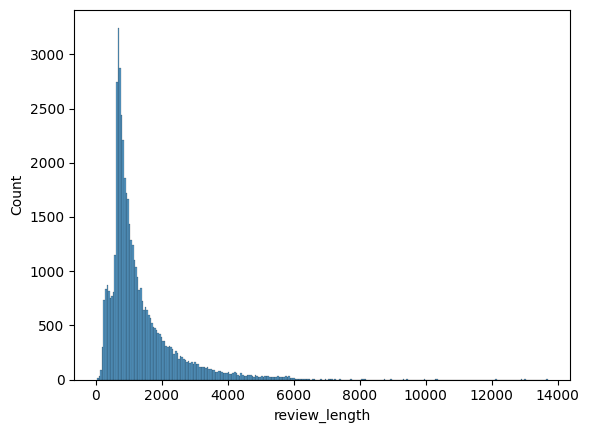

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review_length'])
plt.show()

In [10]:
import re

In [11]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub('<.*?>', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [12]:
df['clean_review'] = df['review'].apply(clean_text)

In [13]:
print(df['review'][0])
print("="*100)
print(df['clean_review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [14]:
df['review_length'] = df['clean_review'].apply(len)

In [15]:
df['review_length'].describe()

,review_length
count,50000.000000
mean,1241.289080
std,939.228917
min,30.000000
25%,665.000000
50%,921.000000
75%,1505.000000
max,13271.000000


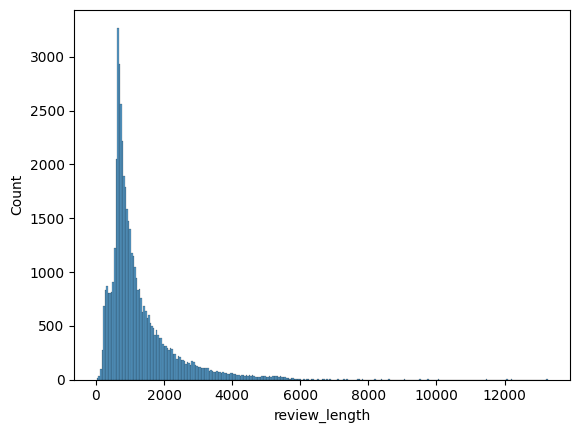

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review_length'])
plt.show()

In [17]:
print(df['review'][0])
print(df['clean_review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [18]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['our', 'there', "they've", 'at', 'be', 'is', 'same', "shouldn't", 'i', 'ma', 'them', 'such', 'won', 'both', 'not', 'under', 'where', "won't", 'being', "it'd"]


In [20]:
def remove_stopwords(text):

    words = text.split()

    filtered = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)

In [21]:
df['clean_review'] = df['clean_review'].apply(remove_stopwords)

In [22]:
print(df['clean_review'][0])

one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cla

In [23]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

In [24]:
def stem_text(text):

    words = text.split()

    stemmed_words = [ps.stem(word) for word in words]

    return " ".join(stemmed_words)

In [26]:
df['clean_review'] = df['clean_review'].apply(stem_text)